## Frank2D CPU 
### Description
This algorithm uses gridded data from gridding the UVTABLE data, to optimize the calculation of the visibilities solution through Frankenstein scheme. 


#### Imports 

In [1]:
import os
import sys
import numpy as np
import time
import scipy
import matplotlib.pyplot as plt
import time


from scipy.stats import binned_statistic
from scipy.interpolate import interp1d
from scipy.sparse.linalg import LinearOperator, splu
from scipy.sparse.linalg._isolve.utils import make_system
from scipy.sparse import csr_matrix

current_dir =  os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
sys.path.append(parent_dir)

#frank2d
from frank2d import Frank2D
from constants import rad_to_arcsec, deg_to_rad
from plot import Plot
from fitting import IterativeSolverMethod
from preprocess_vis import Gridding
from geometry import Geometry

#### Functions

#### BICGM


In [2]:
def _get_atol_rtol(name, b_norm, atol=0., rtol=1e-5):
    """
    A helper function to handle tolerance normalization
    """
    if atol == 'legacy' or atol is None or atol < 0:
        msg = (f"'scipy.sparse.linalg.{name}' called with invalid `atol`={atol}; "
            "if set, `atol` must be a real, non-negative number.")
        raise ValueError(msg)
    
    print(f'         * rtol: {float(rtol)}')
    
    atol = max(float(atol), float(rtol) * float(b_norm))
    print(f'         * final tolerance : {atol}')
    
    return atol, rtol

In [3]:
def bicgstab(A, b, x0=None, *, rtol=1e-7, atol=0., maxiter=None, M=None, callback=None):
        print("     * BICGSTAB")
        A, M, x, b, postprocess = make_system(A, M, x0, b)
        bnrm2 = np.linalg.norm(b)

        atol, _ = _get_atol_rtol('bicgstab', bnrm2, atol, rtol)

        if bnrm2 == 0:
            return postprocess(b), 0

        n = len(b)

        dotprod = np.vdot if np.iscomplexobj(x) else np.dot

        if maxiter is None:
            maxiter = n*10
        print("         * maxiter: ", maxiter)

        matvec = A.matvec
        psolve = M.matvec

        # These values make no sense but coming from original Fortran code
        # sqrt might have been meant instead.
        rhotol = np.finfo(x.dtype.char).eps**2
        omegatol = rhotol

        # Dummy values to initialize vars, silence linter warnings
        rho_prev, omega, alpha, p, v = None, None, None, None, None

        r = b - matvec(x) if x.any() else b.copy()
        rtilde = r.copy()

        for iteration in range(maxiter):
            print(".... iteration: ", iteration)
            tol_ = np.linalg.norm(r) 
            print("                        -> actual tol: ", str(tol_), "vs ", str(atol))
            if tol_ < atol:  # Are we done?
                print(" --------------------------------------> CGM converged in ", iteration, " iterations")
                return postprocess(x), 0

            rho = dotprod(rtilde, r)
            if np.abs(rho) < rhotol:  # rho breakdown
                return postprocess(x), -10

            if iteration > 0:
                if np.abs(omega) < omegatol:  # omega breakdown
                    return postprocess(x), -11

                beta = (rho / rho_prev) * (alpha / omega)
                p -= omega*v
                p *= beta
                p += r
            else:  # First spin
                s = np.empty_like(r)
                p = r.copy()

            phat = psolve(p)
            v = matvec(phat)
            rv = dotprod(rtilde, v)
            if rv == 0:
                return postprocess(x), -11
            alpha = rho / rv
            r -= alpha*v
            s[:] = r[:]

            if np.linalg.norm(s) < atol:
                x += alpha*phat
                return postprocess(x), 0

            shat = psolve(s)
            t = matvec(shat)
            omega = dotprod(t, s) / dotprod(t, t)
            x += alpha*phat
            x += omega*shat
            r -= omega*t
            rho_prev = rho

            if callback:
                callback(x)

        else:  # for loop exhausted
            # Return incomplete progress
            return postprocess(x), maxiter


####  Functions for optimization

In [4]:
def linear_operator(A, size):
    def dot_product(x):
        return A.dot(x)

    return LinearOperator(size, matvec=dot_product)

In [5]:
def P_k(r, k):
    if k == 0:
        return np.ones_like(r)  # P_0(r) = 1
    elif k == 1:
        return 4*r +1  # P_1(r) = 4r + 1
    elif k == 2:
        return (35/3)*r**2 +6*r + 1  # P_2(r) = 35r^2 + 18r + 3
    else:
        raise ValueError("k must be 0, 1, or 2.")

In [6]:
def kernel_row(u, v, i, min_freq, u2 = None, v2 = None, m = -0.33, c = -0.1, l = 1e5):
    def power_spectrum(q, m, c):
        if not np.isscalar(q):  
            q[q == 0] = min_freq
        elif q == 0:
            q = min_freq
        return (q**m)*np.exp(c)
    
    j, k = 4, 1
    H = 2*1.897367*l

    q = np.hypot(u, v)
    power_spectrum_q1 = power_spectrum(q, m, c)
    uh = u/H
    vh = v/H

    q2 = uh2 = vh2 =  None

    if isinstance(u2, np.ndarray):
        q2 = np.hypot(u2[i], v2[i])
        uh2 = u2[i]/H
        vh2 = v2[i]/H
    else:
        q2 = q[i]
        uh2 = uh[i]
        vh2 = vh[i]

    amp = np.sqrt(power_spectrum_q1 * power_spectrum(q2, m, c))
    
    r_normalized = np.sqrt((uh-uh2)**2 + (vh-vh2)**2)
    factor = (1 - r_normalized)**j
    factor[r_normalized > 1] = 0

    return amp * factor * P_k(r_normalized, k)

In [7]:
def create_sparse_kernel(kernel_function, u, v, min_freq, u2 = None, v2 = None ):
    data = []
    indices = []
    indptr = [0]
    size1 = size2 = None

    if isinstance(u2, np.ndarray):
        size1 = len(u2)
        size2 = len(u)
    else:
        size1 = size2 = len(u)

    for i in range(size1):
        row = kernel_function(u, v, i, min_freq, u2 = u2, v2 = v2) if isinstance(u2, np.ndarray) else kernel_function(u, v, i, min_freq)
            
        non_zero_indices = np.nonzero(row)[0]
        kernel_values = row[non_zero_indices]
        
        data.extend(kernel_values)
        indices.extend(non_zero_indices)
        indptr.append(len(data))

    data = np.array(data)
    indices = np.array(indices)
    indptr = np.array(indptr)

    size = (size1, size2)
    kernel_csr = csr_matrix((data, indices, indptr), shape=size)
    kernel = linear_operator(kernel_csr, size)

    return kernel

In [8]:
def create_sparse_system_data(u_gridded_data, v_gridded_data, vis_gridded_data, weights_gridded_data, min_freq):
    N_data = vis_gridded_data.shape[0]
    
    data_A = []
    indices_A = []
    indptr_A = [0]

    data_Aprecond = []
    indices_Aprecond = []
    indptr_Aprecond = [0]
    
    for i in range(N_data):  
        row = kernel_row(u_gridded_data, v_gridded_data, i, min_freq)
        non_zero_indices = np.nonzero(row)[0]
        non_zero_values = row[non_zero_indices]
        Nm1_S_values = non_zero_values * weights_gridded_data[i]

        # A
        diagonal_pos = np.where((non_zero_indices == i))[0][0]
        Nm1_S_values[diagonal_pos] += 1
        diag_value = Nm1_S_values[diagonal_pos]
        
        data_A.extend(Nm1_S_values)
        indices_A.extend(non_zero_indices)
        indptr_A.append(len(data_A))

        # Preconditioner of A
        data_Aprecond.extend([diag_value**(-1)])
        indices_Aprecond.extend([i])
        indptr_Aprecond.append(len(data_Aprecond))
        
    data_A = np.array(data_A)
    indices_A = np.array(indices_A)
    indptr_A = np.array(indptr_A)

    data_Aprecond = np.array(data_Aprecond)
    indices_Aprecond = np.array(indices_Aprecond)
    indptr_Aprecond = np.array(indptr_Aprecond)

    A_csr = csr_matrix((data_A, indices_A, indptr_A), shape=(N_data, N_data))
    A_precond_csr = csr_matrix((data_Aprecond, indices_Aprecond, indptr_Aprecond), shape=(N_data, N_data))

    A = linear_operator(A_csr, (N_data, N_data))
    A_precond = linear_operator(A_precond_csr, (N_data, N_data))
    b = weights_gridded_data * vis_gridded_data

    return A, A_precond, b

### Frank2D CPU

**Params for algorithm: N, u_gridded, v_gridded, Visibilities_gridded, Weights_gridded**

In [9]:
def Frank2D_optimized(N, u_gridded, v_gridded, vis_gridded, weights_gridded, plot = True):
    input = weights_gridded.reshape(N, N)
    data_index = np.argwhere(input.flatten() != 0)
    no_data_index = np.argwhere(input.flatten() == 0) 

    # data
    u_gridded_data = u_gridded[data_index].flatten()
    v_gridded_data = v_gridded[data_index].flatten()
    vis_gridded_data  = vis_gridded[data_index].flatten()
    weights_gridded_data = weights_gridded[data_index].flatten()

    # no data or data with weights == 0.
    u_gridded_no_data = u_gridded[no_data_index].flatten()
    v_gridded_no_data = v_gridded[no_data_index].flatten()
    vis_gridded_no_data  = vis_gridded[no_data_index].flatten()
    weights_gridded_no_data = weights_gridded[no_data_index].flatten()

    #  We intend to solve now:  (I + N^{-1} S_{11})  V* = N^{-1} V_{data} with CGM
    min_freq = np.sort(np.abs(np.unique(v_gridded_data)))[1]

    print("------> Creating linear operators")
    start_time = time.time()
    S11_linearOp = create_sparse_kernel(kernel_row, u_gridded_data, v_gridded_data, min_freq)
    S12_T_linearOp = create_sparse_kernel(kernel_row, u_gridded_data, v_gridded_data, min_freq, u2 = u_gridded_no_data, v2 = v_gridded_no_data)
    end_time = time.time()
    execution_time = end_time - start_time
    print(f'  --> time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')
    print("---------------------------------")

    print("------> Creating sparse system")
    start_time = time.time()
    params = [u_gridded_data, v_gridded_data, vis_gridded_data, weights_gridded_data, min_freq]
    A_opt, A_precond_opt, b_opt = create_sparse_system_data(*params)
    end_time = time.time()
    execution_time = end_time - start_time
    print(f'  --> time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')
    print("---------------------------------")

    print("------> Running CGM")
    start_time = time.time()
    x_data, info = bicgstab(A_opt, b_opt, M = A_precond_opt, rtol = 1e-9)
    C_ = x_data
    end_time = time.time()
    execution_time = end_time - start_time
    print(f'  --> time = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')
    print("---------------------------------")
    
    print("------> CGM converged?  ", info == 0)
    fit_correctly = np.allclose(A_opt.matvec(C_), b_opt)
    print("              --> Fit correctly?  ", fit_correctly)
    if fit_correctly:
        print("                                                     !!!!!!!!!!!!!!!!!!! CORRECT !!!!!!!!!!!!!!!!!!!")
    print("---------------------------------")
    

    def recovering_sol(C):
        V_1_m = S11_linearOp.matvec(C)
        V_2_m = S12_T_linearOp.matvec(C)
        
        V_m = np.zeros((N, N), dtype = 'c16')
        
        data_coords = np.unravel_index(data_index.flatten(), (N, N))
        no_data_coords = np.unravel_index(no_data_index.flatten(), (N, N))
        
        V_m[data_coords] = V_1_m
        V_m[no_data_coords] = V_2_m
    
        u_m = np.zeros((N, N))
        v_m = np.zeros((N, N))
        
        u_m[data_coords] = u_gridded_data
        u_m[no_data_coords] = u_gridded_no_data
        
        v_m[data_coords] = v_gridded_data
        v_m[no_data_coords] = v_gridded_no_data
        
        return V_m

    V_m_2 = recovering_sol(C_)

    if plot:
        plt.pcolormesh(np.fft.fftshift(v_gridded.reshape(N, N)),
               np.fft.fftshift(u_gridded).reshape(N,N),
               np.log(np.abs(np.fft.fftshift(V_m_2))), cmap="viridis", vmin=-12, vmax=-2)
        plt.xlabel(r'u [ $\lambda$]')
        plt.ylabel(r'v [ $\lambda$]')
        plt.gca().set_aspect('equal') 
        cmap = plt.colorbar()
        cmap.set_label(r'V [Jy]', size=15)
        plt.title(r'log|$Vis_{model}$| optimized way')
        plt.show()

    

### Testing

Enforcing Hermitian symmetry...
  --> time = 0.01  min |  0.81 seconds
Setting gridded data...
------> Creating linear operators
  --> time = 0.44  min |  26.60 seconds
---------------------------------
------> Creating sparse system
  --> time = 0.40  min |  23.93 seconds
---------------------------------
------> Running CGM
     * BICGSTAB
         * rtol: 1e-09
         * final tolerance : 0.24673735471999497
         * maxiter:  78570
.... iteration:  0
                        -> actual tol:  246737354.71999496 vs  0.24673735471999497
.... iteration:  1
                        -> actual tol:  52448822.26021391 vs  0.24673735471999497
.... iteration:  2
                        -> actual tol:  36140386.20972905 vs  0.24673735471999497
.... iteration:  3
                        -> actual tol:  26621091.83002371 vs  0.24673735471999497
.... iteration:  4
                        -> actual tol:  18676817.14155876 vs  0.24673735471999497
.... iteration:  5
                        -> actua

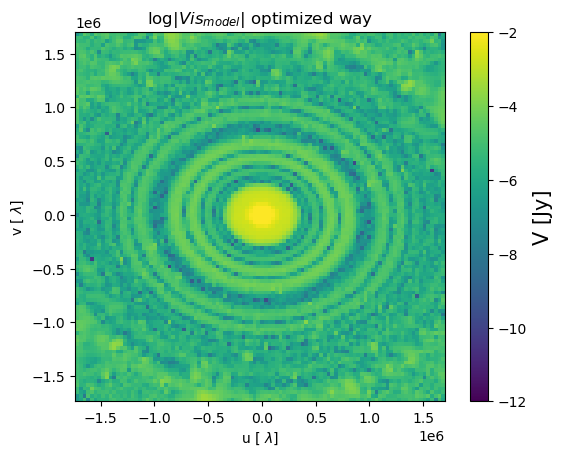

  ------------------------------------------> TOTAL ALGORITHM TIME = 4.72  min |  283.49 seconds


In [13]:
disk_name = 'AS209 1mm'

# Huang 2018 
inc = 34.97
pa = 85.76
dra = 1.9e-3
ddec = -2.5e-3
Rout = 3 #arcsecs

# UVtable
dir = "./../../data/"
data_file = dir +'AS209_continuum_prom_1chan_30s_keepflagsFalse.txt'

 # load data
u, v, Re, Imag, Weights = np.loadtxt(data_file, unpack = True)
Vis = Re + Imag*1j

N = 100
geom = Geometry(inc, pa, dra, ddec)
frank2d = Frank2D(N, Rout, geom)

start_time = time.time()

frank2d.preprocess_vis(u, v, Vis, Weights, hermitian= True)
u_gridded, v_gridded, vis_gridded, weights_gridded = frank2d._gridded_data['u'], frank2d._gridded_data['v'], frank2d._gridded_data['vis'], frank2d._gridded_data['weights']
sol = Frank2D_optimized(N, u_gridded, v_gridded, vis_gridded, weights_gridded)

end_time = time.time()
execution_time = end_time - start_time
print(f'  ------------------------------------------> TOTAL ALGORITHM TIME = {execution_time/60 :.2f}  min | {execution_time: .2f} seconds')


**WORKS**